# Loan Approval Prediction System using Machine Learning

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import os
import joblib

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [6]:
os.makedirs("images", exist_ok=True)
os.makedirs("model", exist_ok=True)

In [7]:
df = pd.read_csv("dataset/loan_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
print(df.head())

    loan_id gender married dependents     education self_employed  \
0  lp001002   male      no          0      graduate            no   
1  lp001003   male     yes          1      graduate            no   
2  lp001005   male     yes          0      graduate           yes   
3  lp001006   male     yes          0  not graduate            no   
4  lp001008   male      no          0      graduate            no   

   applicantincome  coapplicantincome  loanamount  loan_amount_term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   credit_history property_area loan_status  
0             1.0         urban           y  
1             1.0         rural           n  
2             1.0   

In [9]:
print("Dataset shape:", df.shape)

Dataset shape: (614, 13)


In [10]:
print("Column names:")
print(df.columns)

Column names:
Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='str')


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    str    
 1   gender             601 non-null    str    
 2   married            611 non-null    str    
 3   dependents         599 non-null    str    
 4   education          614 non-null    str    
 5   self_employed      582 non-null    str    
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         592 non-null    float64
 9   loan_amount_term   600 non-null    float64
 10  credit_history     564 non-null    float64
 11  property_area      614 non-null    str    
 12  loan_status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [13]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
loan_id               0
gender               13
married               3
dependents           15
education             0
self_employed        32
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
loan_status           0
dtype: int64


In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
categorical_columns = [
    "gender",
    "married",
    "dependents",
    "self_employed"
]

for column in categorical_columns:df[column] = df[column].fillna(df[column].mode()[0])


print("Categorical missing values handled.")

Categorical missing values handled.


In [16]:
numerical_columns = [
    "loanamount",
    "loan_amount_term",
    "credit_history"
]

for column in numerical_columns: df[column] = df[column].fillna(df[column].median())


print("Numerical missing values handled.")

Numerical missing values handled.


In [17]:
df["gender"] = df["gender"].map({ "male": 1,"female": 0})

print("Gender converted.")

Gender converted.


In [18]:
df["married"] = df["married"].map({"yes": 1,"no": 0})

print("Married converted.")

Married converted.


In [19]:
df["education"] = df["education"].map({"graduate": 1,"not graduate": 0})

print("Education converted.")

Education converted.


In [20]:
df["self_employed"] = df["self_employed"].map({"yes": 1,"no": 0})

print("Self employed converted.")

Self employed converted.


In [21]:
df["dependents"] = df["dependents"].replace({"3+": 3})


df["dependents"] = pd.to_numeric(df["dependents"])


print("Dependents converted.")

Dependents converted.


In [22]:
df = pd.get_dummies(df,columns=["property_area"],drop_first=True,dtype=int)


print("Property area converted.")

Property area converted.


In [23]:
df["loan_status"] = df["loan_status"].map({"y": 1,"n": 0})


print("Loan status converted.")

Loan status converted.


In [24]:
print(df.head())

    loan_id  gender  married  dependents  education  self_employed  \
0  lp001002       1        0           0          1              0   
1  lp001003       1        1           1          1              0   
2  lp001005       1        1           0          1              1   
3  lp001006       1        1           0          0              0   
4  lp001008       1        0           0          1              0   

   applicantincome  coapplicantincome  loanamount  loan_amount_term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   credit_history  loan_status  property_area_semiurban  property_area_urban  
0             1.0            1                        0                  

In [25]:
print("Missing values after preprocessing:")

print(df.isnull().sum())

Missing values after preprocessing:
loan_id                    0
gender                     0
married                    0
dependents                 0
education                  0
self_employed              0
applicantincome            0
coapplicantincome          0
loanamount                 0
loan_amount_term           0
credit_history             0
loan_status                0
property_area_semiurban    0
property_area_urban        0
dtype: int64


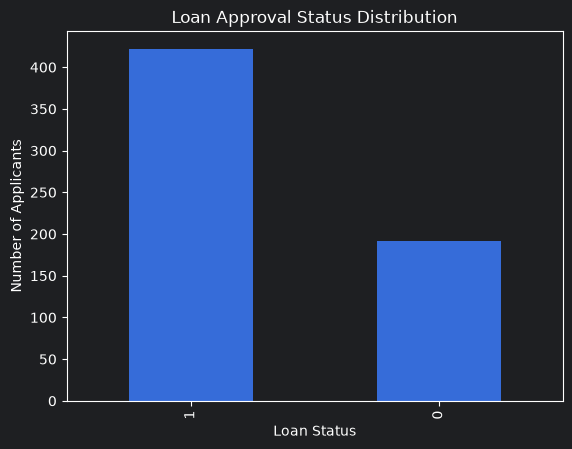

In [26]:
df["loan_status"].value_counts().plot(kind="bar")



plt.title("Loan Approval Status Distribution")

plt.xlabel("Loan Status")

plt.ylabel("Number of Applicants")

plt.savefig("images/loan_status_distribution.png")

plt.show()

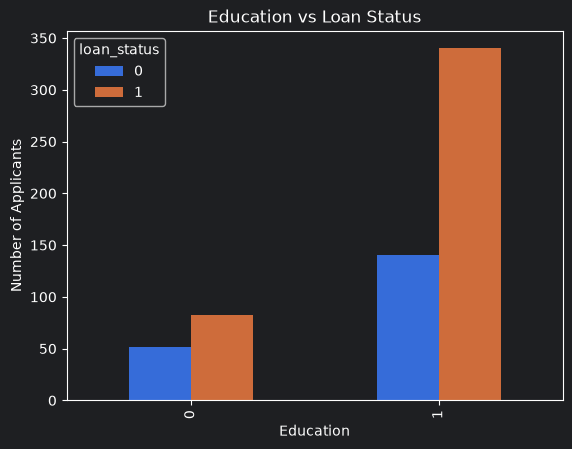

In [27]:
pd.crosstab(df["education"],df["loan_status"]).plot( kind="bar")


plt.title("Education vs Loan Status")

plt.xlabel("Education")

plt.ylabel("Number of Applicants")

plt.savefig( "images/education_vs_loan_status.png")

plt.show()

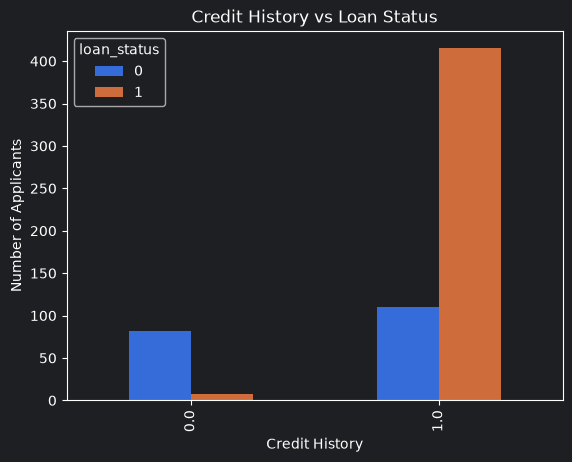

In [28]:
pd.crosstab(df["credit_history"],df["loan_status"]).plot(kind="bar")


plt.title("Credit History vs Loan Status")

plt.xlabel("Credit History")

plt.ylabel("Number of Applicants")

plt.savefig("images/credit_history_vs_loan_status.png")

plt.show()

In [29]:
features = [
    "gender",
    "married",
    "dependents",
    "education",
    "self_employed",
    "applicantincome",
    "coapplicantincome",
    "loanamount",
    "loan_amount_term",
    "credit_history",
    "property_area_semiurban",
    "property_area_urban"
]


X = df[features]
y = df["loan_status"]


print("Features selected.")

Features selected.


In [30]:
print("Features used:")

print(X.columns)

Features used:
Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area_semiurban',
       'property_area_urban'],
      dtype='str')


In [31]:
print("X shape:", X.shape)

print("y shape:", y.shape)

X shape: (614, 12)
y shape: (614,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


print("Training data:", X_train.shape)

print("Testing data:", X_test.shape)

Training data: (491, 12)
Testing data: (123, 12)


In [33]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train,y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


C:\Users\user\Loan_Approval_Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train,y_train)

print("Decision Tree trained.")

Decision Tree trained.


In [35]:
logistic_pred = logistic_model.predict(X_test)

decision_tree_pred = decision_tree.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [36]:
print(" ACCURACY ")

print("Logistic Regression:",accuracy_score(y_test, logistic_pred))

print("Decision Tree:",accuracy_score(y_test, decision_tree_pred))

 ACCURACY 
Logistic Regression: 0.8536585365853658
Decision Tree: 0.7398373983739838


In [37]:
print(" PRECISION ")

print("Logistic Regression:",precision_score(y_test,logistic_pred,zero_division=0))

print("Decision Tree:",precision_score(y_test,decision_tree_pred,zero_division=0))

 PRECISION 
Logistic Regression: 0.8383838383838383
Decision Tree: 0.8271604938271605


In [38]:
print(" RECALL ")

print("Logistic Regression:",recall_score(y_test,logistic_pred,zero_division=0))

print("Decision Tree:",recall_score(y_test,decision_tree_pred,zero_division=0))

 RECALL 
Logistic Regression: 0.9764705882352941
Decision Tree: 0.788235294117647


In [39]:
print("F1 SCORE ")

print("Logistic Regression:",f1_score(y_test,logistic_pred,zero_division=0))

print("Decision Tree:",f1_score(y_test,decision_tree_pred,zero_division=0))

F1 SCORE 
Logistic Regression: 0.9021739130434783
Decision Tree: 0.8072289156626506


In [40]:
print("CONFUSION MATRICES ")

print("Logistic Regression:")
print(confusion_matrix(y_test,logistic_pred))

print("\nDecision Tree:")
print(confusion_matrix(y_test,decision_tree_pred))

CONFUSION MATRICES 
Logistic Regression:
[[22 16]
 [ 2 83]]

Decision Tree:
[[24 14]
 [18 67]]


In [41]:
logistic_accuracy = accuracy_score(y_test,logistic_pred)

decision_tree_accuracy = accuracy_score(y_test,decision_tree_pred)


print("Logistic Regression:",logistic_accuracy)

print("Decision Tree:",decision_tree_accuracy)

Logistic Regression: 0.8536585365853658
Decision Tree: 0.7398373983739838


In [42]:
if logistic_accuracy > decision_tree_accuracy:

    best_model = logistic_model

    best_model_name = "Logistic Regression"

    best_accuracy = logistic_accuracy


else:
    best_model = decision_tree

    best_model_name = "Decision Tree"

    best_accuracy = decision_tree_accuracy


print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: Logistic Regression
Best Accuracy: 0.8536585365853658


In [43]:
new_applicant = pd.DataFrame({
    "gender": [1],
    "married": [1],
    "dependents": [0],
    "education": [1],
    "self_employed": [0],
    "applicantincome": [5000],
    "coapplicantincome": [2000],
    "loanamount": [150],
    "loan_amount_term": [360],
    "credit_history": [1.0],
    "property_area_semiurban": [0],
    "property_area_urban": [1]
})


print(new_applicant)

   gender  married  dependents  education  self_employed  applicantincome  \
0       1        1           0          1              0             5000   

   coapplicantincome  loanamount  loan_amount_term  credit_history  \
0               2000         150               360             1.0   

   property_area_semiurban  property_area_urban  
0                        0                    1  


In [44]:
prediction = best_model.predict(new_applicant)

print("Prediction:", prediction[0])

Prediction: 1


In [45]:
if prediction[0] == 1:
    print("Loan Status: APPROVED")


else:
    print("Loan Status: REJECTED")

Loan Status: APPROVED


In [46]:
joblib.dump(best_model,"model/best_loan_model.pkl")


print("Best model saved successfully.")

Best model saved successfully.
